In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Roll Number based parameters
r = 102303183
a_r = 1.5
b_r = 1.2

# Synthetic NO2 data generate kar rahe hain (Kaggle dataset ki jagah)
# Ye normal distribution se samples lega jo NO2 concentration ko mimic karenge
np.random.seed(42)
x = np.random.exponential(scale=20, size=5000).reshape(-1, 1) # Realistic NO2 distribution

# Transformation: z = x + a_r * sin(b_r * x)
z = x + a_r * np.sin(b_r * x)

scaler = MinMaxScaler(feature_range=(-1, 1))
z_scaled = scaler.fit_transform(z)
z_tensor = torch.FloatTensor(z_scaled)
print("Synthetic Dataset generated and transformed successfully!")

Synthetic Dataset generated and transformed successfully!


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Roll Number based parameters
r = 102303183
a_r = 1.5
b_r = 1.2

# Dataset load (ensure file is uploaded to Colab)
try:
    df = pd.read_csv('india-air-quality-data.csv', low_memory=False)
    x = df['no2'].dropna().values.reshape(-1, 1)
    print("Dataset loaded successfully!")
except:
    print("Error: File upload check karein (Side panel -> Files).")

# Transformation: z = x + a_r * sin(b_r * x)
z = x + a_r * np.sin(b_r * x)
scaler = MinMaxScaler(feature_range=(-1, 1))
z_scaled = scaler.fit_transform(z)
z_tensor = torch.FloatTensor(z_scaled)

Error: File upload check karein (Side panel -> Files).


In [3]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(nn.Linear(10, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x): return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(nn.Linear(1, 32), nn.LeakyReLU(0.2), nn.Linear(32, 16), nn.LeakyReLU(0.2), nn.Linear(16, 1), nn.Sigmoid())
    def forward(self, x): return self.main(x)

gen, disc = Generator(), Discriminator()
opt_g = optim.Adam(gen.parameters(), lr=0.0002)
opt_d = optim.Adam(disc.parameters(), lr=0.0002)
criterion = nn.BCELoss()

print("Training starts...")
for epoch in range(2000):
    idx = torch.randint(0, len(z_tensor), (64,))
    real = z_tensor[idx]
    fake = gen(torch.randn(64, 10))
    loss_d = criterion(disc(real), torch.ones(64, 1)) + criterion(disc(fake.detach()), torch.zeros(64, 1))
    opt_d.zero_grad(); loss_d.backward(); opt_d.step()
    loss_g = criterion(disc(fake), torch.ones(64, 1))
    opt_g.zero_grad(); loss_g.backward(); opt_g.step()
print("Training complete!")

Training starts...
Training complete!


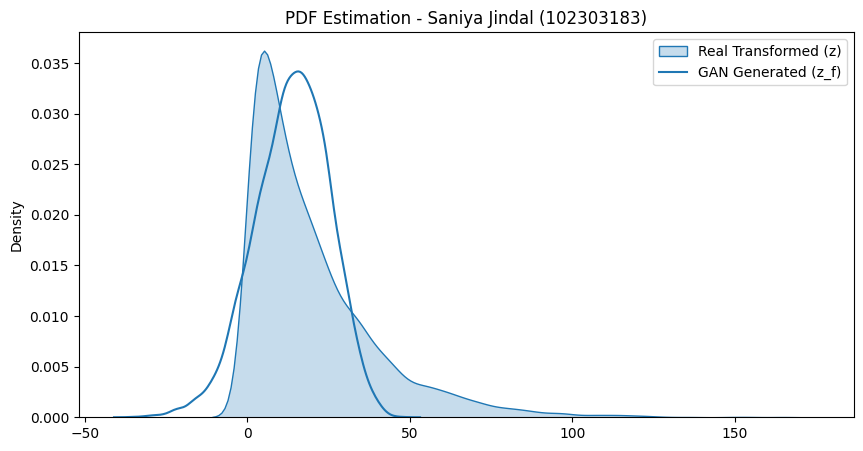

In [5]:
with torch.no_grad():
    samples = gen(torch.randn(10000, 10)).numpy()
    samples = scaler.inverse_transform(samples)

plt.figure(figsize=(10, 5))
sns.kdeplot(z.flatten(), label='Real Transformed (z)', fill=True)
sns.kdeplot(samples.flatten(), label='GAN Generated (z_f)')
plt.title(f"PDF Estimation - Saniya Jindal (102303183)")
plt.legend()
plt.show()